## **Gradient Boosting for Regression from Scratch**

### **Topic Roadmap**

**1. Load a real regression dataset**

**2. Fit an initial constant model**

**3. Implement regression stumps**

**4. Fit residual learners iteratively**

**5. Key revision notes**

## **1. One-Feature Regression Data**

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

cars = pd.read_csv("docs/Lecture-086-cars.csv")
X = cars[["wt"]].to_numpy(dtype=float)
y = cars["mpg"].to_numpy(dtype=float)
order = np.argsort(X[:, 0])
X, y = X[order], y[order]
X = (X - X.mean()) / X.std()

## **2. Regression Stump**

A regression stump searches one threshold and predicts the mean target on each side. It is sufficient to illustrate gradient boosting mechanics.

In [3]:
def fit_regression_stump(x, residual):
    thresholds = (x[:-1] + x[1:]) / 2
    best = None
    for threshold in thresholds:
        left = x <= threshold
        right = ~left
        if left.sum() == 0 or right.sum() == 0:
            continue
        left_value = residual[left].mean()
        right_value = residual[right].mean()
        prediction = np.where(left, left_value, right_value)
        loss = np.mean((residual - prediction) ** 2)
        if best is None or loss < best["loss"]:
            best = {"threshold": threshold, "left_value": left_value, "right_value": right_value, "loss": loss}
    return best

In [4]:
def predict_stump(stump, x):
    return np.where(x <= stump["threshold"], stump["left_value"], stump["right_value"])

## **3. Gradient-Boosting Loop**

For squared-error loss, the negative gradient is the residual `y - prediction`. Each new stump fits the current residuals.

In [5]:
def gradient_boost_regression(X, y, n_estimators=30, learning_rate=0.05):
    x = X[:, 0]
    prediction = np.full(y.shape, y.mean(), dtype=float)
    stumps = []
    for _ in range(n_estimators):
        residual = y - prediction
        stump = fit_regression_stump(x, residual)
        update = predict_stump(stump, x)
        prediction += learning_rate * update
        stumps.append(stump)
    return y.mean(), stumps, prediction

In [6]:
initial_value, stumps, fitted = gradient_boost_regression(X, y)
print("Final training RMSE:", np.mean((y - fitted) ** 2) ** 0.5)

Final training RMSE: 2.993603037488398


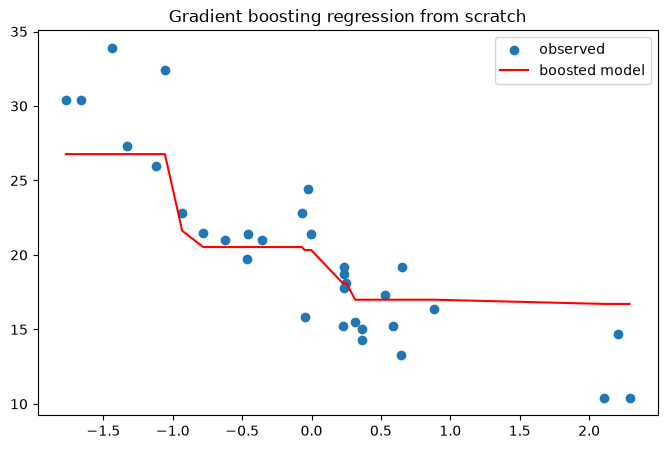

In [7]:
def predict_boosted_regression(initial_value, stumps, X, learning_rate=0.05):
    prediction = np.full(X.shape[0], initial_value, dtype=float)
    x = X[:, 0]
    for stump in stumps:
        prediction += learning_rate * predict_stump(stump, x)
    return prediction

plt.figure(figsize=(8, 5))
plt.scatter(X[:, 0], y, label="observed")
plt.plot(X[:, 0], predict_boosted_regression(initial_value, stumps, X), color="red", label="boosted model")
plt.legend()
plt.title("Gradient boosting regression from scratch")
plt.show()

### **Key Revision Notes**

- Start with a constant prediction that minimizes squared error.
- Fit each weak learner to the current residuals.
- Add only a fraction of each learner through `learning_rate`.
- The model is additive: the final prediction is the initial value plus all scaled updates.